<a href="https://colab.research.google.com/github/unknxwNS/Ihopeitworks/blob/main/%D0%9B%D0%A04_%D0%9C%D1%96%D1%85%D0%B0%D0%BB%D1%8C%D0%BE%D0%B2_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота №4. Регресійні моделі: глибоке дослідження

**Датасет:** Car Price Prediction Multiple Linear Regression  
https://www.kaggle.com/datasets/hellbuoy/car-price-prediction?select=CarPrice_Assignment.csv

**Мета роботи:** виконати підготовку даних, побудувати та порівняти регресійні моделі для прогнозування ціни автомобіля, оцінити їх якість і проаналізувати отримані результати.

> У шаблоні наведено лише умови завдань. Реалізацію необхідно виконати самостійно у порожніх комірках.


## 1. Завантаження та первинний аналіз даних

Завантажити датасет та виконати його первинний огляд:
- визначити кількість об'єктів і ознак;
- переглянути назви стовпців;
- визначити типи даних;
- визначити цільову змінну;
- вивести основні статистичні характеристики даних.


In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

path = kagglehub.dataset_download("hellbuoy/car-price-prediction")
df = pd.read_csv(os.path.join(path, "CarPrice_Assignment.csv"))

display(df.head())


Using Colab cache for faster access to the 'car-price-prediction' dataset.


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


**car_IDУ** - нікальний ідентифікатор автомобіля

**symboling** - Категорія страхового ризику автомобіля

**CarName** - Марка та модель автомобіля

**fueltype** - Тип пального (gas, diesel)

**aspiration** - Тип подачі повітря до двигуна: стандартний або турбований

**doornumber** - Кількість дверей

**carbody** - Тип кузова автомобіля

**drivewheel** - Тип приводу: передній, задній або повний

**enginelocation** - Розташування двигуна
**wheelbase** - Колісна база автомобіля
**carlength** - Довжина автомобіля
**carwidth** - Ширина автомобіля
**carheight** - Висота автомобіля
**curbweight** - Споряджена маса автомобіля

**enginetype** - Тип двигуна

**cylindernumber** - Кількість циліндрів

**enginesize** - Робочий об'єм/розмір двигуна

**fuelsystem** - Тип паливної системи

**boreratio** - Діаметр циліндра / характеристика отвору циліндра

**stroke** - Хід поршня

**compressionratio** - Ступінь стиснення двигуна

**horsepower** - Потужність двигуна

**peakrpm** - Максимальна частота обертання двигуна

**citympg** - Паливна економічність під час руху містом

**highwaympg** - Паливна економічність на шосе

**price** - Ціна автомобіля — цільова змінна

In [5]:
print("Розмір датасету:", df.shape)
df.info

Розмір датасету: (205, 26)


<bound method DataFrame.info of      car_ID  symboling                   CarName fueltype aspiration  \
0         1          3        alfa-romero giulia      gas        std   
1         2          3       alfa-romero stelvio      gas        std   
2         3          1  alfa-romero Quadrifoglio      gas        std   
3         4          2               audi 100 ls      gas        std   
4         5          2                audi 100ls      gas        std   
..      ...        ...                       ...      ...        ...   
200     201         -1           volvo 145e (sw)      gas        std   
201     202         -1               volvo 144ea      gas      turbo   
202     203         -1               volvo 244dl      gas        std   
203     204         -1                 volvo 246   diesel      turbo   
204     205         -1               volvo 264gl      gas      turbo   

    doornumber      carbody drivewheel enginelocation  wheelbase  ...  \
0          two  convertible        rwd          front       88.6  ...   
1          two  convertible        rwd          front       88.6  ...   
2          two    hatchback        rwd          front       94.5  ...   
3         four        sedan        fwd          front       99.8  ...   
4         four        sedan        4wd          front       99.4  ...   
..         ...          ...        ...            ...        ...  ...   
200       four        sedan        rwd          front      109.1  ...   
201       four        sedan        rwd          front      109.1  ...   
202       four        sedan        rwd          front      109.1  ...   
203       four        sedan        rwd          front      109.1  ...   
204       four        sedan        rwd          front      109.1  ...   

     enginesize  fuelsystem  boreratio  stroke compressionratio horsepower  \
0           130        mpfi       3.47    2.68              9.0        111   
1           130        mpfi       3.47    2.68              9.0        111   
2           152        mpfi       2.68    3.47              9.0        154   
3           109        mpfi       3.19    3.40             10.0        102   
4           136        mpfi       3.19    3.40              8.0        115   
..          ...         ...        ...     ...              ...        ...   
200         141        mpfi       3.78    3.15              9.5        114   
201         141        mpfi       3.78    3.15              8.7        160   
202         173        mpfi       3.58    2.87              8.8        134   
203         145         idi       3.01    3.40             23.0        106   
204         141        mpfi       3.78    3.15              9.5        114   

     peakrpm citympg  highwaympg    price  
0       5000      21          27  13495.0  
1       5000      21          27  16500.0  
2       5000      19          26  16500.0  
3       5500      24          30  13950.0  
4       5500      18          22  17450.0  
..       ...     ...         ...      ...  
200     5400      23          28  16845.0  
201     5300      19          25  19045.0  
202     5500      18          23  21485.0  
203     4800      26          27  22470.0  
204     5400      19          25  22625.0  

[205 rows x 26 columns]>

## 2. Перевірка якості даних

Перевірити:
- наявність пропущених значень;
- наявність повних дублікатів;
- кількість унікальних значень в ознаках.

Під час аналізу врахувати, що `car_ID` є унікальним ідентифікатором автомобіля і сам по собі не повинен використовуватися для визначення дублікатів за змістовими характеристиками.


In [6]:
print("Кількість пропущених значень:")
display(df.isna().sum().sort_values(ascending=False))

print("Повні дублікати:", df.duplicated().sum())

print(
    "Дублікати без урахування car_ID:",
    df.drop(columns="car_ID").duplicated().sum()
)

Кількість пропущених значень:


,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


Повні дублікати: 0
Дублікати без урахування car_ID: 0


## 3. Робота з car_ID

Зберегти `car_ID` окремо для подальшої ідентифікації автомобілів у результатах прогнозування.  
Не використовувати `car_ID` як ознаку під час навчання моделей.


In [7]:
# car_ID зберігаємо для фінального виведення прогнозів, але не подаємо в модель
ids = df["car_ID"].copy()

# CarName має високу кардинальність, тому залишаємо тільки марку автомобіля
df_model = df.copy()

df_model["brand"] = (
    df_model["CarName"]
    .str.lower()
    .str.split()
    .str[0]
    .replace({
        "maxda": "mazda",
        "porcshce": "porsche",
        "toyouta": "toyota",
        "vokswagen": "volkswagen",
        "vw": "volkswagen"
    })
)

# Видаляємо car_ID та CarName
df_model = df_model.drop(columns=["car_ID", "CarName"])

## 4. Дослідження розподілів числових ознак

Дослідити розподіли числових ознак:
- побудувати відповідні графіки;
- обчислити коефіцієнти асиметрії;
- визначити ознаки з найбільш вираженою асиметрією;
- коротко прокоментувати отримані результати.


,skewness
compressionratio,2.610862
enginesize,1.947655
price,1.777678
horsepower,1.405310
wheelbase,1.050214
carwidth,0.904003
stroke,-0.689705
curbweight,0.681398
citympg,0.663704
highwaympg,0.539997


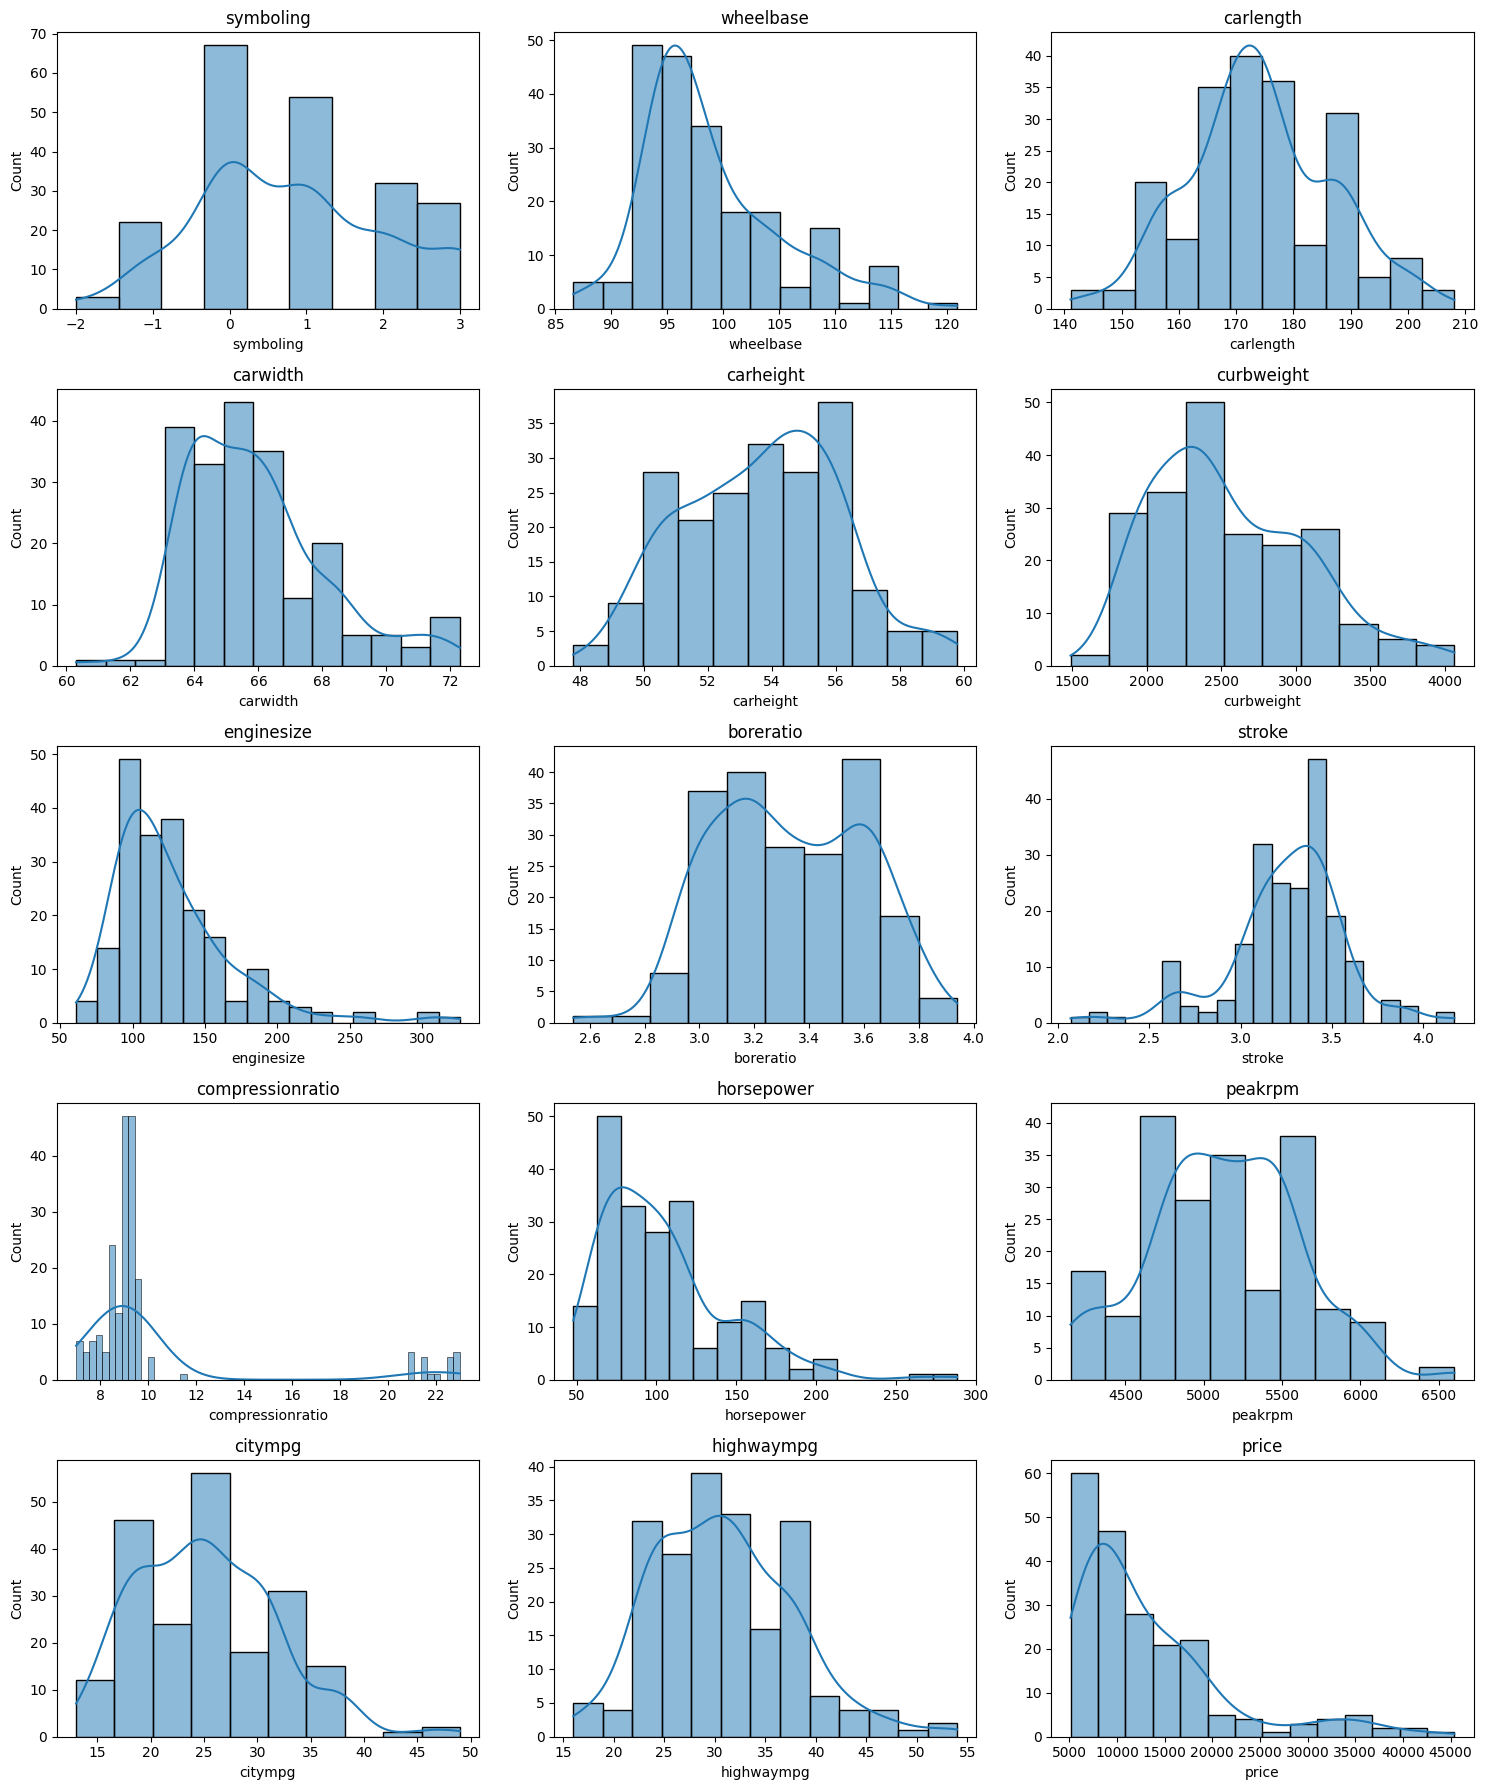

In [8]:
numeric_initial = df_model.select_dtypes(include=np.number).columns

skew_initial = df_model[numeric_initial].skew().sort_values(
    key=np.abs, ascending=False
)

display(skew_initial.to_frame("skewness"))

n_cols = 3
n_rows = int(np.ceil(len(numeric_initial) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(15, 3.6 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_initial):
    sns.histplot(df_model[col], kde=True, ax=ax)
    ax.set_title(col)

for ax in axes[len(numeric_initial):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Формування train/test вибірок

Відокремити цільову змінну `price` від ознак та розділити дані на:
- навчальну вибірку — 80%;
- тестову вибірку — 20%.

Забезпечити відтворюваність поділу.  
Окремо зберегти `car_ID` для об'єктів, які потрапили до train і test.

**Важливо:** усі подальші параметри передобробки даних визначати тільки за навчальною вибіркою.


In [9]:
X = df_model.drop(columns ="price")

y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

id_train = ids.loc[X_train.index]
id_test = ids.loc[X_test.index]


print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (164, 24) Test: (41, 24)


## 6. Аналіз та обробка викидів

Для неперервних числових ознак навчальної вибірки:
- визначити потенційні викиди методом IQR;
- вивести кількість потенційних викидів для кожної ознаки;
- обґрунтувати спосіб їх обробки.

Для невеликого набору даних не видаляти автоматично всі рядки з викидами. Використати обмеження крайніх значень межами, визначеними за навчальною вибіркою.

Цільову змінну `price` не використовувати для визначення меж викидів.  
До тестової вибірки застосувати ті самі межі, які були отримані за train.


In [10]:
continuous_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns
    if c != "symboling"
]

# Обчислюємо межі викидів методом IQR.
# Усі статистики визначаємо тільки за навчальною вибіркою X_train,
# щоб інформація з тестової вибірки не впливала на підготовку даних.

# Перший квартиль (25-й перцентиль)
q1 = X_train[continuous_cols].quantile(0.25)

# Третій квартиль (75-й перцентиль)
q3 = X_train[continuous_cols].quantile(0.75)

# Міжквартильний розмах
iqr = q3 - q1

# Нижня межа допустимих значень
lower_bounds = q1 - 1.5 * iqr

upper_bounds = q3 + 1.5 * iqr

outlier_counts = (
    (X_train[continuous_cols].lt(lower_bounds)) |
    (X_train[continuous_cols].gt(upper_bounds))
).sum().sort_values(ascending=False)

# Виводимо кількість потенційних викидів для кожної ознаки.
# Ознаки сортуються від найбільшої кількості викидів до найменшої.
display(outlier_counts.to_frame("potential_outliers_train"))

# Створюємо копії вибірок, щоб не змінювати початкові DataFrame.
X_train = X_train.copy()
X_test = X_test.copy()

# У навчальній вибірці:
# - значення нижче нижньої межі замінюємо нижньою межею;
# - значення вище верхньої межі замінюємо верхньою межею.
X_train[continuous_cols] = X_train[continuous_cols].clip(
    lower=lower_bounds,
    upper=upper_bounds,
    axis=1
)

# До тестової вибірки застосовуємо ті самі межі,
# які були розраховані на основі X_train.
# Межі повторно не обчислюємо, щоб уникнути витоку інформації.
X_test[continuous_cols] = X_test[continuous_cols].clip(
    lower=lower_bounds,
    upper=upper_bounds,
    axis=1
)

,potential_outliers_train
compressionratio,20
stroke,16
carwidth,10
horsepower,7
enginesize,7
wheelbase,6
peakrpm,2
highwaympg,1
boreratio,1
curbweight,0


## 7. Аналіз кореляцій та відбір ознак

За навчальною вибіркою:
- побудувати матрицю кореляцій числових ознак;
- знайти пари ознак із сильною кореляцією, для яких `|r| > 0.85`;
- для кожної такої пари залишити одну ознаку;
- під час вибору врахувати силу зв'язку кожної ознаки з цільовою змінною `price`;
- вивести список сильно корельованих пар та перелік ознак, які видаляються.

Із тестової вибірки видалити ті самі ознаки.  
Не використовувати тестову вибірку для прийняття рішення про відбір ознак.


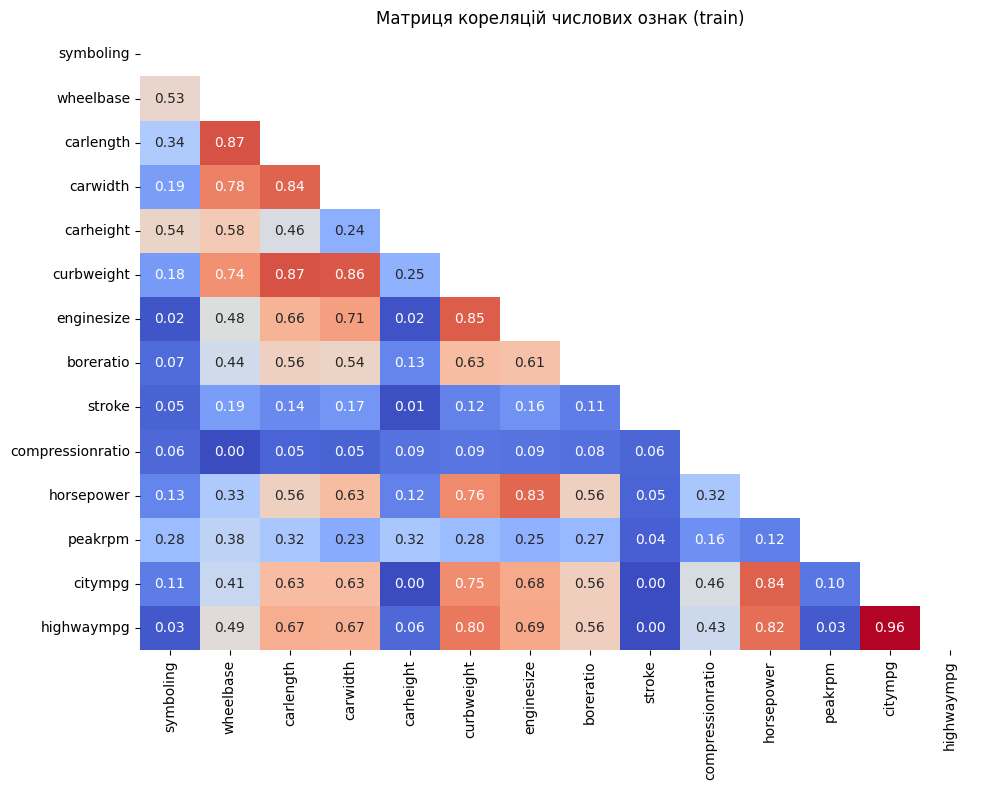

Сильно корельовані пари (|r| > 0.85):
wheelbase — carlength: r = 0.867
carlength — curbweight: r = 0.866
carwidth — curbweight: r = 0.858
citympg — highwaympg: r = 0.964

Ознаки для видалення:
['carlength', 'carwidth', 'citympg', 'wheelbase']

Розміри після відбору ознак:
Train: (164, 20)
Test: (41, 20)


In [14]:
# Визначаємо числові ознаки у навчальній вибірці
numeric_train_cols = X_train.select_dtypes(include=np.number).columns


# Матриця кореляцій числових ознак
corr_matrix = X_train[numeric_train_cols].corr()


# Будуємо теплову карту
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix.abs(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    mask=np.triu(np.ones_like(corr_matrix, dtype=bool)),
    cbar=False
)

plt.title("Матриця кореляцій числових ознак (train)")
plt.tight_layout()
plt.show()


# Знаходимо пари ознак із сильною кореляцією |r| > 0.85
pairs = []

for i in range(len(numeric_train_cols)):
    for j in range(i + 1, len(numeric_train_cols)):

        a = numeric_train_cols[i]
        b = numeric_train_cols[j]

        r = corr_matrix.loc[a, b]

        if abs(r) > 0.85:
            pairs.append((a, b, r))


# Визначаємо кореляцію кожної ознаки з цільовою змінною price
target_corr = X_train[numeric_train_cols].corrwith(y_train)


# Для кожної сильно корельованої пари
# залишаємо ознаку з сильнішим зв'язком із price
features_to_drop = set()

for a, b, r in pairs:

    if abs(target_corr[a]) < abs(target_corr[b]):
        features_to_drop.add(a)
    else:
        features_to_drop.add(b)


# Виводимо знайдені пари
print("Сильно корельовані пари (|r| > 0.85):")

for a, b, r in pairs:
    print(f"{a} — {b}: r = {r:.3f}")


# Виводимо ознаки, які видаляємо
print("\nОзнаки для видалення:")
print(sorted(features_to_drop))


# Видаляємо вибрані ознаки з train
X_train = X_train.drop(
    columns=list(features_to_drop)
)


# Видаляємо ТОЧНО ті самі ознаки з test
X_test = X_test.drop(
    columns=list(features_to_drop)
)


print("\nРозміри після відбору ознак:")
print("Train:", X_train.shape)
print("Test:", X_test.shape)

## 8. Підготовка числових і категоріальних ознак

Розділити ознаки на:
- неперервні числові;
- дискретну числову ознаку `symboling`;
- категоріальні.

Для неперервних числових ознак виконати послідовно:
1. перетворення Yeo–Johnson для зменшення асиметрії;
2. масштабування за допомогою StandardScaler.

Для `symboling` виконати масштабування без Yeo–Johnson.

Категоріальні ознаки закодувати методом One-Hot Encoding. Передбачити коректну обробку категорій у test, яких не було у train.

Усі перетворення об'єднати в єдиний механізм передобробки даних, який навчається тільки на `X_train`.


In [19]:
# Визначаємо неперервні числові ознаки.
# Ознака symboling не включається, оскільки вона є дискретною
# порядковою ознакою, а не неперервною величиною.
continuous_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns
    if c != "symboling"
]


# Виділяємо дискретну числову ознаку symboling окремо.
ordinal_numeric_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns
    if c == "symboling"
]


# Визначаємо категоріальні ознаки.
categorical_cols = (
    X_train
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)


# Pipeline для неперервних числових ознак.

# Перетворення Yeo-Johnson використовується
# для зменшення асиметрії розподілів.
# standardize=False, оскільки масштабування
# виконується окремим кроком StandardScaler.

numeric_pipeline = Pipeline(steps=[
    ("power", PowerTransformer(
        method="yeo-johnson",
        standardize=False
    )),

    # Масштабуємо числові ознаки:
    # середнє значення ≈ 0,
    # стандартне відхилення ≈ 1.
    ("scaler", StandardScaler())
])


# Pipeline для дискретної числової ознаки symboling.
# Yeo-Johnson до неї не застосовуємо,
# але масштабуємо для моделей, чутливих до масштабу
# (Linear Regression, Ridge, Lasso, SVR).
ordinal_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])


# Pipeline для категоріальних ознак.
categorical_pipeline = Pipeline(steps=[

    # One-Hot Encoding перетворює категорії
    # на набір бінарних ознак.
    #
    # handle_unknown="ignore" дозволяє обробляти
    # у test категорії, яких не було в train.
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


# Об'єднуємо всі етапи попередньої обробки.
# ВАЖЛИВО:
# усі трансформери навчаються тільки на X_train,
# оскільки preprocess входить до Pipeline моделі.

preprocessor = ColumnTransformer(
    transformers=[

        # Неперервні числові:
        # 1. Yeo-Johnson — зменшує асиметрію розподілу;
        # 2. StandardScaler — приводить ознаки до єдиного масштабу.
        ("continuous", numeric_pipeline, continuous_cols),

        # Дискретна числова:
        # StandardScaler.
        ("ordinal", ordinal_pipeline, ordinal_numeric_cols),

        # Категоріальні:
        # One-Hot Encoding.
        ("categorical", categorical_pipeline, categorical_cols),
    ],

    # Інші стовпці не передаємо до моделі.
    remainder="drop",

    # Не додаємо префікси continuous__, ordinal__, categorical__
    # до назв ознак.
    verbose_feature_names_out=False,
)


# Перевірка результату PowerTransformer

# Для демонстраційної перевірки використовуємо
# той самий pipeline, що буде застосовуватися у моделях.

# clone() створює незалежну копію pipeline,
# тому основний preprocessor ще не навчається.
num_check = clone(numeric_pipeline)


# Навчаємо pipeline тільки на неперервних числових
# ознаках навчальної вибірки.
num_train_transformed = pd.DataFrame(
    num_check.fit_transform(
        X_train[continuous_cols]
    ),
    columns=continuous_cols,
    index=X_train.index
)


# Перевіряємо асиметрію розподілів після трансформації.
#
# Чим ближче skewness до 0,
# тим більш симетричним є розподіл ознаки.
skewness_after = (
    num_train_transformed
    .skew()
    .sort_values(
        key=np.abs,
        ascending=False
    )
)

display(
    skewness_after.to_frame("skewness_after")
)

,skewness_after
horsepower,0.066280
curbweight,0.049894
enginesize,0.044834
stroke,0.015846
highwaympg,-0.012188
boreratio,-0.005941
carheight,-0.005170
compressionratio,0.004872
peakrpm,-0.003589


## 9. Перевірка трансформації числових ознак

Перевірити результат трансформації неперервних числових ознак:
- застосувати до train ту саму послідовність перетворень, яка буде використана в моделях;
- повторно обчислити коефіцієнти асиметрії;
- порівняти їх із початковими значеннями;
- зробити короткий висновок щодо ефективності трансформації.


In [20]:
# Створюємо словник регресійних моделей,
# які будемо навчати та порівнювати між собою.
estimators = {

    # Linear Regression — базова лінійна модель.
    # Оцінює лінійну залежність між ознаками
    # та цільовою змінною price.
    "Linear Regression": LinearRegression(),

    # Ridge Regression — лінійна регресія
    # з L2-регуляризацією.
    #
    # Регуляризація зменшує великі значення коефіцієнтів
    # і може знизити ризик перенавчання.
    #
    # alpha визначає силу регуляризації.
    "Ridge": Ridge(
        alpha=1.0
    ),

    # Lasso Regression — лінійна регресія
    # з L1-регуляризацією.
    #
    # Lasso може зменшувати деякі коефіцієнти до нуля,
    # фактично виконуючи додатковий відбір ознак.
    #
    # max_iter збільшено для забезпечення
    # достатньої кількості ітерацій для збіжності.
    "Lasso": Lasso(
            alpha=1.0,
    max_iter=20000
),

# Random Forest — ансамблева модель,
# що будує множину дерев рішень
# та усереднює їхні прогнози.
#
# n_estimators=500 — кількість дерев.
# random_state=42 — відтворюваність результатів.
# n_jobs=-1 — використання всіх доступних ядер процесора.
"Random Forest": RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
),

# Gradient Boosting — ансамблевий метод,
# у якому дерева будуються послідовно.
#
# Кожне наступне дерево намагається
# скоригувати помилки попередніх.
"Gradient Boosting": GradientBoostingRegressor(
    random_state=42
),
    # Support Vector Regression (SVR) — метод опорних векторів для задачі регресії.
# SVR є чутливим до масштабу ознак,
# тому попереднє масштабування числових ознак є особливо важливим.
"SVR": SVR(),
}


# Для кожної моделі створюємо окремий Pipeline.

# Pipeline забезпечує послідовне виконання:

# 1. preprocess — попередня обробка ознак:
#
#    неперервні числові ознаки:
# Yeo-Johnson → StandardScaler;
#
# symboling:
# StandardScaler;
#
# категоріальні ознаки:
# OneHotEncoder.
# 2. model — навчання відповідної
# регресійної моделі.
#
# ВАЖЛИВО:
# preprocessor навчається тільки під час fit()
# відповідного Pipeline на X_train.
# Тестова вибірка не використовується
# для оцінювання параметрів перетворень.

models = {

    name: Pipeline(steps=[

        # Для кожної моделі створюємо незалежну
        # копію preprocessor.
        ("preprocess", clone(preprocessor)),

        # Після попередньої обробки дані
        # передаються відповідній регресійній моделі.
        ("model", estimator),

    ])

    for name, estimator in estimators.items()
}

## 10. Побудова регресійних моделей

Побудувати та навчити такі моделі:
- Linear Regression;
- Ridge Regression;
- Lasso Regression;
- Random Forest Regressor;
- Gradient Boosting Regressor;
- Support Vector Regressor (SVR).

Для кожної моделі створити єдиний Pipeline, який містить:
1. попередню обробку ознак;
2. відповідну регресійну модель.

Використати однакову схему підготовки даних для коректного порівняння моделей.


In [22]:
# Створюємо порожній список для збереження
# результатів оцінювання всіх моделей.
results = []


# Створюємо словник для збереження прогнозів
# кожної моделі на тестовій вибірці.
#
# Він знадобиться надалі для побудови графіків
# та детального аналізу прогнозів.
predictions = {}


# Послідовно навчаємо та оцінюємо кожну модель.
for name, model in models.items():

    # Навчаємо весь Pipeline на навчальній вибірці.
    #
    # Усередині Pipeline спочатку навчається preprocessor:
    # - PowerTransformer;
    # - StandardScaler;
    # - OneHotEncoder.
    #
    # Після цього на підготовлених даних
    # навчається відповідна регресійна модель.
    model.fit(X_train, y_train)


    # Отримуємо прогнози значень price
    # для тестової вибірки.
    y_pred = model.predict(X_test)


    # Зберігаємо прогнози кожної моделі
    # для подальшого аналізу.
    predictions[name] = y_pred


    # Обчислюємо метрики якості моделі
    # тільки на тестовій вибірці.
    results.append({

        # Назва моделі.
        "Model": name,

        # R² — коефіцієнт детермінації.
        # Показує, яку частину варіації цільової змінної
        # пояснює модель.
        #
        # Чим ближче R² до 1, тим вищий показник.
        "R2": r2_score(
            y_test,
            y_pred
        ),


        # MAE — середня абсолютна помилка.
        #
        # Показує середню абсолютну різницю
        # між фактичною та прогнозованою ціною.
        # Вимірюється в тих самих одиницях, що й price.
        #
        # Чим менше MAE, тим менше середня помилка.
        "MAE": mean_absolute_error(
            y_test,
            y_pred
        ),


        # MSE — середня квадратична помилка.
        #
        # Сильніше штрафує великі помилки,
        # оскільки різниця підноситься до квадрату.
        #
        # Чим менше MSE, тим менша помилка.
        "MSE": mean_squared_error(
            y_test,
            y_pred
        ),


        # MAPE — середня абсолютна відсоткова помилка.
        #
        # Показує, на скільки відсотків у середньому
        # прогноз моделі відрізняється від фактичної ціни.
        #
        # sklearn повертає значення у частках,
        # тому множимо результат на 100.
        #
        # Чим менше MAPE, тим менша відносна помилка.
        "MAPE, %": mean_absolute_percentage_error(
            y_test,
            y_pred
        ) * 100
    })


# Перетворюємо результати у DataFrame.

# Сортуємо моделі за R² від найбільшого
# до найменшого значення.
results_df = (
    pd.DataFrame(results)
    .sort_values(
        "R2",
        ascending=False
    )
    .reset_index(drop=True)
)


# Виводимо підсумкову таблицю
# з результатами всіх моделей.
display(results_df)

,Model,R2,MAE,MSE,"MAPE, %"
0,Random Forest,0.954906,1318.781760,3.559886e+06,9.695253
1,Gradient Boosting,0.930420,1727.403684,5.492942e+06,12.050186
2,Linear Regression,0.879431,2156.098245,9.518236e+06,16.376447
3,Lasso,0.878234,2105.214295,9.612671e+06,15.133568
4,Ridge,0.853789,2367.223583,1.154249e+07,18.193087
5,SVR,-0.099732,5696.776966,8.681724e+07,36.027666


## 11. Оцінювання якості моделей

Для кожної моделі:
- виконати навчання на тренувальній вибірці;
- отримати прогноз для тестової вибірки;
- обчислити метрики **R², MAE, MSE та MAPE**.

`MAPE` подати у відсотках.

Результати всіх моделей об'єднати в одну порівняльну таблицю та впорядкувати за значенням R² від найбільшого до найменшого.

Під час інтерпретації врахувати:
- R² — чим більше, тим краще;
- MAE, MSE, MAPE — чим менше, тим краще.


## 12. Пояснення вибору типу моделі

Пояснити, чому класифікаційна модель, наприклад Logistic Regression, не підходить для безпосереднього прогнозування неперервної ціни автомобіля.

Зазначити, до якого типу задачі належить прогнозування `price` та чому моделі, використані в роботі, відповідають цій задачі.


## 13. Візуальне порівняння прогнозів

Для кожної побудованої моделі зобразити співвідношення:
- фактичних значень `price`;
- прогнозованих значень `price`.

Додати лінію ідеального прогнозу та проаналізувати, наскільки близько до неї розташовані прогнозовані значення. Звернути увагу на великі відхилення.


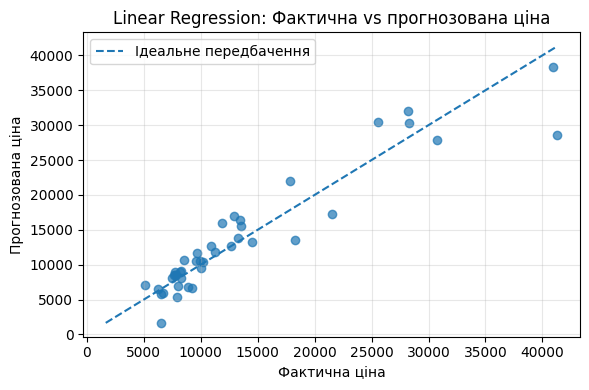

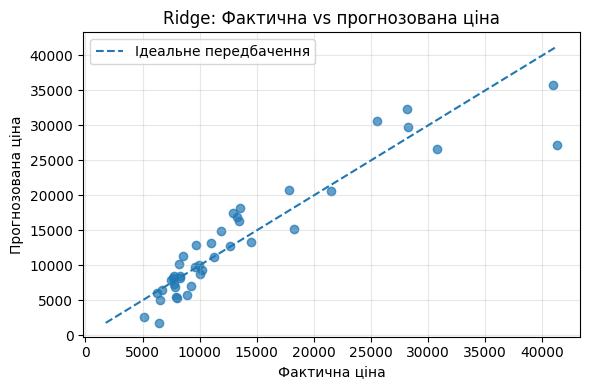

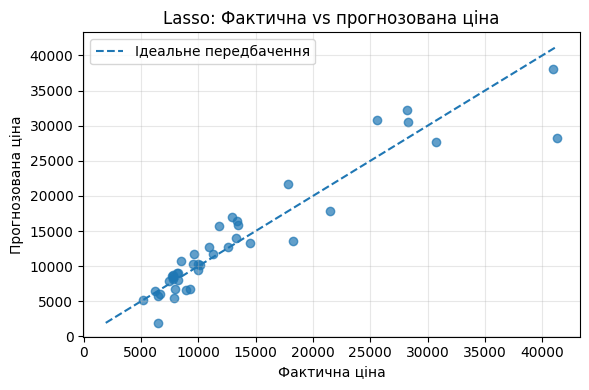

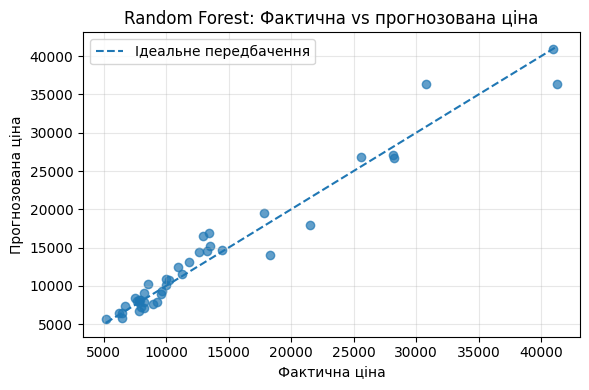

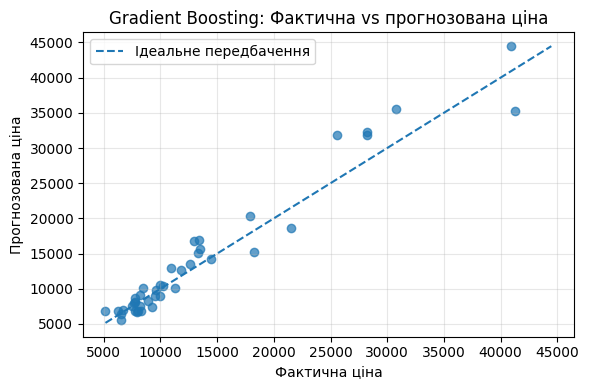

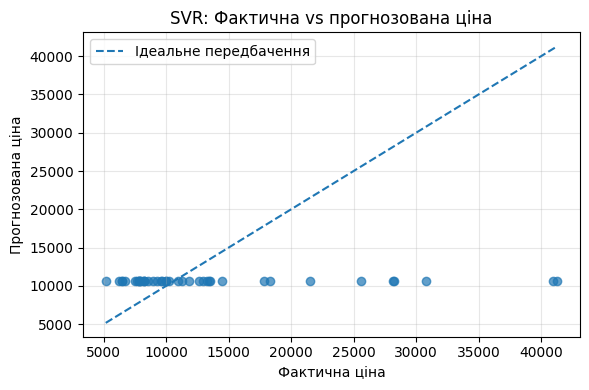

In [23]:
y_true = y_test.to_numpy()

for name, y_pred in predictions.items():
    y_pred = np.asarray(y_pred).ravel()

    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(6, 4))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.plot(
        [lo, hi],
        [lo, hi],
        "--",
        label="Ідеальне передбачення"
    )
    plt.xlabel("Фактична ціна")
    plt.ylabel("Прогнозована ціна")
    plt.title(f"{name}: Фактична vs прогнозована ціна")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 14. Прогноз для 10 автомобілів

Випадково вибрати 10 автомобілів із тестової вибірки.

За допомогою моделі Random Forest отримати для них прогноз ціни та сформувати таблицю з такими даними:
- `car_ID`;
- фактична ціна;
- прогнозована ціна;
- абсолютна помилка;
- абсолютна відсоткова помилка.

Прокоментувати отримані результати.


In [24]:
# Отримуємо вже навчену модель Random Forest
# зі словника models.
#
# ВАЖЛИВО: цей блок потрібно запускати після навчання моделей,
# тобто після виконання model.fit(X_train, y_train)
# у попередньому блоці.
rf_model = models["Random Forest"]


# Випадково обираємо 10 автомобілів із тестової вибірки.
#
# Якщо у X_test менше 10 об'єктів, будуть використані всі.
# random_state=42 забезпечує однаковий вибір автомобілів
# при повторному запуску коду.
sample_idx = X_test.sample(
    n=min(10, len(X_test)),
    random_state=42
).index


# Отримуємо прогнози ціни для вибраних автомобілів.
#
# Усередині Pipeline автоматично виконується
# та сама попередня обробка ознак,
# яка використовувалась під час навчання моделі.
sample_pred = rf_model.predict(
    X_test.loc[sample_idx]
)


# Формуємо таблицю для порівняння
# фактичних і прогнозованих цін.
sample_rf = pd.DataFrame({
# Ідентифікатор автомобіля.
# car_ID не використовувався для навчання моделі,
# а зберігається окремо для ідентифікації об'єктів.
"car_ID": id_test.loc[sample_idx].to_numpy(),

# Фактична ціна автомобіля.
"Actual price": y_test.loc[sample_idx].to_numpy(),

# Ціна, спрогнозована моделлю Random Forest.
"Predicted price (RF)": sample_pred
})
# Обчислюємо абсолютну помилку прогнозу
# для кожного вибраного автомобіля.
sample_rf["Absolute error"] = (
    sample_rf["Actual price"]
    - sample_rf["Predicted price (RF)"]
).abs()


# Обчислюємо абсолютну відсоткову помилку прогнозу.
sample_rf["Absolute percentage error, %"] = (
    sample_rf["Absolute error"]
    / sample_rf["Actual price"]
    * 100
)


# Виводимо результати прогнозування
# для 10 випадково вибраних автомобілів.
display(sample_rf)

,car_ID,Actual price,Predicted price (RF),Absolute error,"Absolute percentage error, %"
0,26,6692.0,7316.599000,624.599000,9.333518
1,176,9988.0,10940.662000,952.662000,9.538066
2,148,10198.0,10797.708167,599.708167,5.880645
3,17,41315.0,36371.429000,4943.571000,11.965560
4,69,28248.0,26661.713000,1586.287000,5.615573
5,147,7463.0,8367.516333,904.516333,12.120010
6,144,9960.0,10117.517667,157.517667,1.581503
7,85,14489.0,14688.636000,199.636000,1.377845
8,195,12940.0,16470.556000,3530.556000,27.284049
9,160,7788.0,7907.148000,119.148000,1.529892


## 15. Висновки

Сформулювати підсумкові висновки за результатами роботи.

У висновках:
- порівняти якість усіх моделей;
- проаналізувати R², MAE, MSE і MAPE;
- зазначити, яка модель показала найкращі результати за отриманими метриками;
- прокоментувати величину похибок;
- звернути увагу на можливі ознаки перенавчання;
- коротко оцінити вплив попередньої обробки даних на результати моделювання.


## Загальні вимоги до виконання

- Не використовувати тестову вибірку для визначення меж викидів, кореляційного відбору ознак, навчання трансформерів, масштабування або кодування категорій.
- Усі параметри передобробки мають визначатися тільки за навчальною вибіркою.
- Фінальні метрики моделей обчислювати на тестовій вибірці.
- Не використовувати `car_ID` як предиктор.
- Не видаляти спостереження або ознаки без пояснення причини.
- До кожного основного етапу додати короткий змістовний висновок.
- У підсумкових висновках спиратися на отримані метрики та графіки.
